# 09 – Heterogeneidade: CATE (RQ2)

Objetivo: estimar como o efeito de cada estratégia varia de acordo com o contexto (tipo de dataset e modelo).
Reutilizamos a lógica e código da T5 (notebook 08), mas condicionando a análise nos subgrupos de Z.
Recortes: `ir_bin`, `model_family3` e `task3`.
Células com amostra muito pequena (n < 10) são explicitamente marcadas.


In [8]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

NB_DIR        = Path().resolve()
PROJECT_DIR   = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

df = pd.read_parquet(PROCESSED_DIR / "analysis_dataset.parquet")

STRATS     = ["oversampling", "cost_sensitive", "undersampling", "other"]
PRINCIPAIS = {"oversampling", "cost_sensitive"}
RNG        = np.random.default_rng(42)

# Limiar para marcar células com amostra pequena
N_MIN = 10

print(f"Pares: {len(df)} | grupos: {df['within_paper_group_id'].nunique()}")
print(df["strategy"].value_counts().reindex(STRATS).to_string())


Pares: 425 | grupos: 279
strategy
oversampling      156
cost_sensitive     79
undersampling      32
other             158


## Preparação do desfecho e de Z

Reutilizamos a mesma winsorização e as mesmas covariáveis Z da T5.


In [9]:
# Winsorização idêntica ao notebook 08
lo, hi = df["delta_y"].quantile([0.01, 0.99])
df["delta_y_w"] = df["delta_y"].clip(lo, hi)

COMMON   = ["ir_bin", "nclasses_bin", "size_bin", "task3", "model_family3"]
CAT_COLS = ["strategy"] + COMMON
CATS     = {c: sorted(df[c].dropna().unique()) for c in CAT_COLS}

# Dimensões de heterogeneidade para os recortes do CATE
HETEROG_DIMS = {
    "ir_bin":         "Bin de IR (taxa de desbalanceamento)",
    "model_family3":  "Família de modelo",
    "task3":          "Tipo de tarefa",
}

print("Ajuste backdoor por Z:", COMMON)
print("Dimensões de heterogeneidade:", list(HETEROG_DIMS.keys()))


Ajuste backdoor por Z: ['ir_bin', 'nclasses_bin', 'size_bin', 'task3', 'model_family3']
Dimensões de heterogeneidade: ['ir_bin', 'model_family3', 'task3']


## Funções auxiliares (reutilizadas da T5)


In [10]:
def make_design(data):
    """Monta a matriz de design para a regressão linear (g-fórmula)."""
    d = data.copy()
    for c in CAT_COLS:
        d[c] = pd.Categorical(d[c], categories=CATS[c])
    X = pd.get_dummies(d[CAT_COLS], drop_first=True).astype(float)
    X.insert(0, "intercept", 1.0)
    return X.values

def adjusted_means(data, outcome):
    """Calcula médias ajustadas por g-fórmula (regressão linear)."""
    X = make_design(data)
    y = data[outcome].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    out = {}
    for s in STRATS:
        d = data.copy(); d["strategy"] = s
        out[s] = float((make_design(d) @ beta).mean())
    return out

def cluster_bootstrap(data, outcome, n_boot=1000):
    """Cluster bootstrap por within_paper_group_id."""
    groups = {g: d for g, d in data.groupby("within_paper_group_id")}
    gids = np.array(list(groups.keys()))
    draws = {s: [] for s in STRATS}
    for _ in range(n_boot):
        ids  = RNG.choice(gids, size=len(gids), replace=True)
        boot = pd.concat([groups[g] for g in ids], ignore_index=True)
        m = adjusted_means(boot, outcome)
        for s in STRATS:
            draws[s].append(m[s])
    return {s: (np.percentile(draws[s], 2.5),
                np.percentile(draws[s], 97.5)) for s in STRATS}


## Função genérica para calcular CATE condicionado


In [11]:
def compute_cate_by_dimension(df, dimension, outcome="delta_y_w", n_boot=1000):
    """
    Computa CATE para cada subgrupo de uma dimensão de heterogeneidade.
    """
    results = []
    for val in sorted(df[dimension].dropna().unique()):
        sub = df[df[dimension] == val].copy()
        
        for s in STRATS:
            n_s = int((sub["strategy"] == s).sum())
            
            # Se n muito baixo, marcar mas ainda calcular se possível
            if n_s < 2:
                results.append({
                    "dimensão":   dimension,
                    "subgrupo":   val,
                    "estratégia": s,
                    "n":          n_s,
                    "efeito % (wins.)": np.nan,
                    "IC95% baixo":      np.nan,
                    "IC95% alto":       np.nan,
                    "cruza 0?":         "—",
                    "n_baixo":          True,
                })
                continue
        
        # Ponto estimado
        try:
            point = adjusted_means(sub, outcome)
        except Exception:
            for s in STRATS:
                n_s = int((sub["strategy"] == s).sum())
                results.append({
                    "dimensão": dimension, "subgrupo": val,
                    "estratégia": s, "n": n_s,
                    "efeito % (wins.)": np.nan,
                    "IC95% baixo": np.nan, "IC95% alto": np.nan,
                    "cruza 0?": "falha", "n_baixo": True,
                })
            continue
        
        # Bootstrap IC
        try:
            ci = cluster_bootstrap(sub, outcome, n_boot=n_boot)
        except Exception:
            ci = {s: (np.nan, np.nan) for s in STRATS}
        
        for s in STRATS:
            eff = point[s] * 100
            lo_, hi_ = ci[s][0] * 100, ci[s][1] * 100
            n_s = int((sub["strategy"] == s).sum())
            
            # Se a estimativa point for NaN
            if pd.isna(point[s]):
                eff = np.nan
            
            results.append({
                "dimensão":   dimension,
                "subgrupo":   val,
                "estratégia": s,
                "n":          n_s,
                "efeito % (wins.)": round(eff, 2) if not pd.isna(eff) else np.nan,
                "IC95% baixo":      round(lo_, 2) if not pd.isna(lo_) else np.nan,
                "IC95% alto":       round(hi_, 2) if not pd.isna(hi_) else np.nan,
                "cruza 0?":   "sim" if lo_ <= 0 <= hi_ else "NÃO",
                "n_baixo":    n_s < N_MIN,
            })
    
    return pd.DataFrame(results)


## CATE por bin de IR

O bin de IR captura a taxa de desbalanceamento do dataset.


In [12]:
cate_ir = compute_cate_by_dimension(df, "ir_bin")
print(cate_ir.to_string(index=False))


dimensão subgrupo     estratégia  n  efeito % (wins.)  IC95% baixo  IC95% alto cruza 0?  n_baixo
  ir_bin      1-2   oversampling 34              6.84         3.61       10.53      NÃO    False
  ir_bin      1-2 cost_sensitive  3              4.28         0.51       10.26      NÃO     True
  ir_bin      1-2  undersampling  7             -4.40       -20.89        6.54      sim     True
  ir_bin      1-2          other 15              4.03         1.59        7.92      NÃO    False
  ir_bin      2-5 cost_sensitive  1               NaN          NaN         NaN        —     True
  ir_bin      2-5   oversampling 36             20.74         8.49       43.21      NÃO    False
  ir_bin      2-5 cost_sensitive  1             48.23         4.03       74.86      NÃO     True
  ir_bin      2-5  undersampling  5             -1.89       -41.81       31.04      sim     True
  ir_bin      2-5          other 13             32.51         8.93       58.85      NÃO    False
  ir_bin     5-10  undersampli

## CATE por família de modelo


In [13]:
cate_model = compute_cate_by_dimension(df, "model_family3")
print(cate_model.to_string(index=False))


     dimensão      subgrupo     estratégia  n  efeito % (wins.)  IC95% baixo  IC95% alto cruza 0?  n_baixo
model_family3 kernel_linear cost_sensitive  0               NaN          NaN         NaN        —     True
model_family3 kernel_linear   oversampling 38              9.17         5.00       14.92      NÃO    False
model_family3 kernel_linear cost_sensitive  0             15.31        -0.12       33.81      sim     True
model_family3 kernel_linear  undersampling  7             21.61       -29.95       91.60      sim     True
model_family3 kernel_linear          other 20             10.04         0.52       17.15      NÃO    False
model_family3        neural   oversampling 39             35.25        -7.99       81.13      sim    False
model_family3        neural cost_sensitive 76             14.06         2.45       37.41      NÃO    False
model_family3        neural  undersampling 12             -3.59       -39.24       36.47      sim    False
model_family3        neural          

## CATE por tipo de tarefa


In [14]:
cate_task = compute_cate_by_dimension(df, "task3")
print(cate_task.to_string(index=False))


dimensão subgrupo     estratégia   n  efeito % (wins.)  IC95% baixo  IC95% alto cruza 0?  n_baixo
   task3    other   oversampling  10              4.76        -5.11       19.91      sim    False
   task3    other cost_sensitive  46              6.49         2.88        9.90      NÃO    False
   task3    other  undersampling   2             21.26         5.45       43.73      NÃO     True
   task3    other          other  51              9.26         4.79       13.99      NÃO    False
   task3  tabular   oversampling 140             39.63        18.95       69.34      NÃO    False
   task3  tabular cost_sensitive  13             38.15         3.45       84.26      NÃO    False
   task3  tabular  undersampling  28             49.15       -19.22      154.75      sim    False
   task3  tabular          other  84             67.25        24.27      120.38      NÃO    False
   task3   vision   oversampling   6             43.00        -1.31      106.96      sim     True
   task3   vision co

## Tabela consolidada e exportação


In [15]:
cate_all = pd.concat([cate_ir, cate_model, cate_task], ignore_index=True)
cate_all.to_csv(PROCESSED_DIR / "cate_resultados.csv", index=False)
print(f"Salvo: data/processed/cate_resultados.csv  ({len(cate_all)} linhas)")


Salvo: data/processed/cate_resultados.csv  (53 linhas)


## Visualização: Forest Plots por dimensão


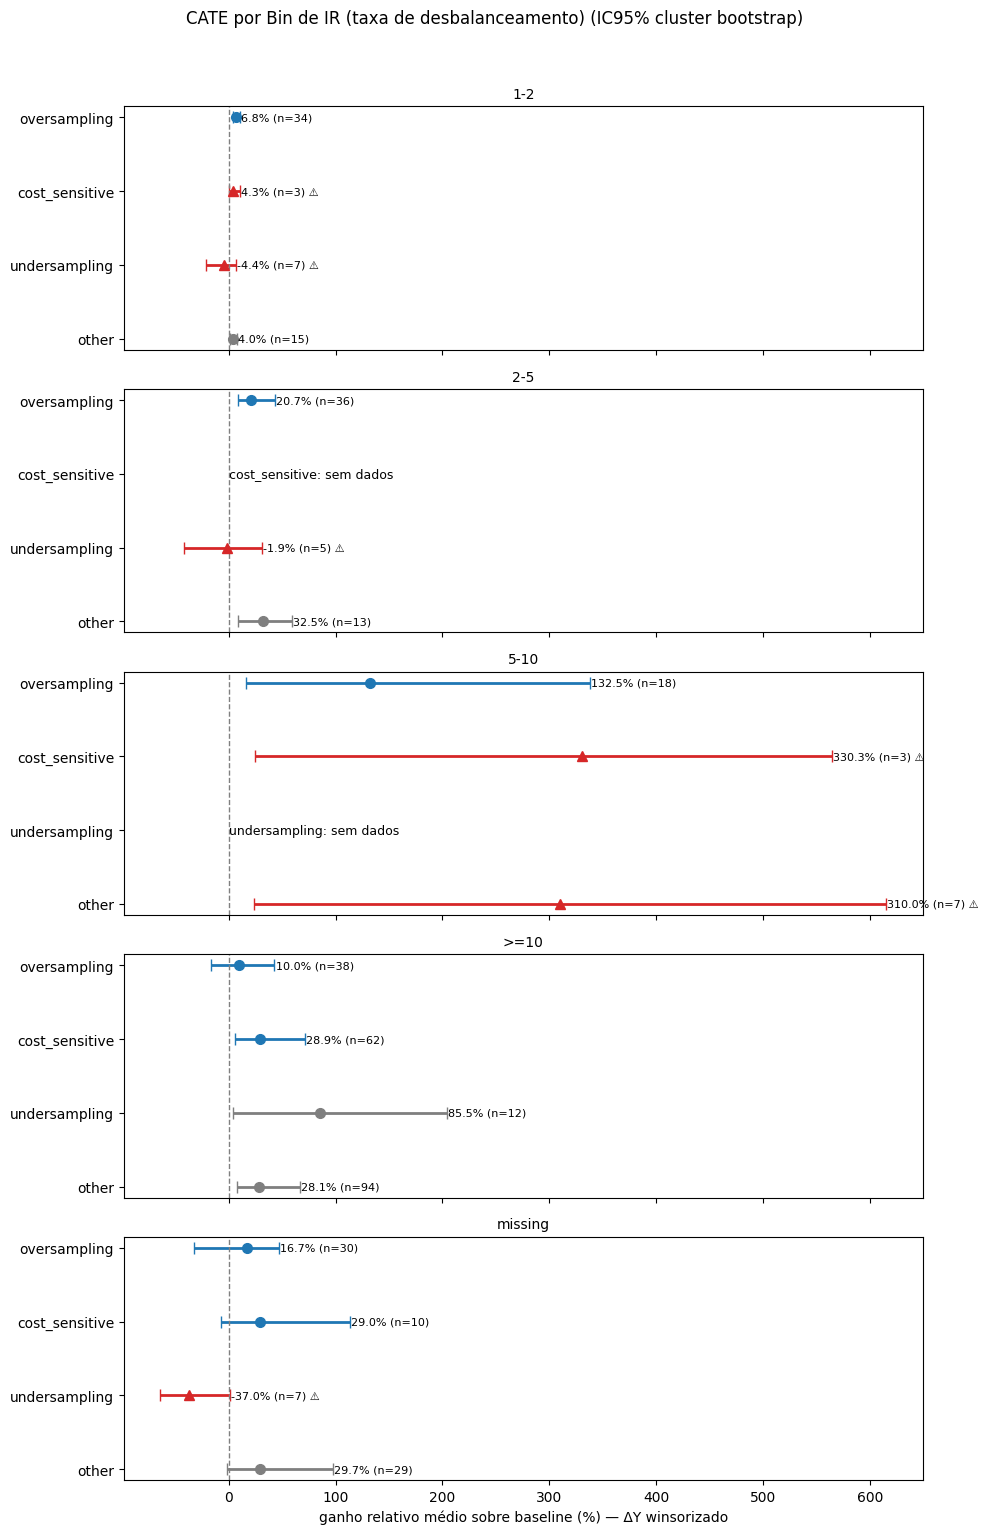

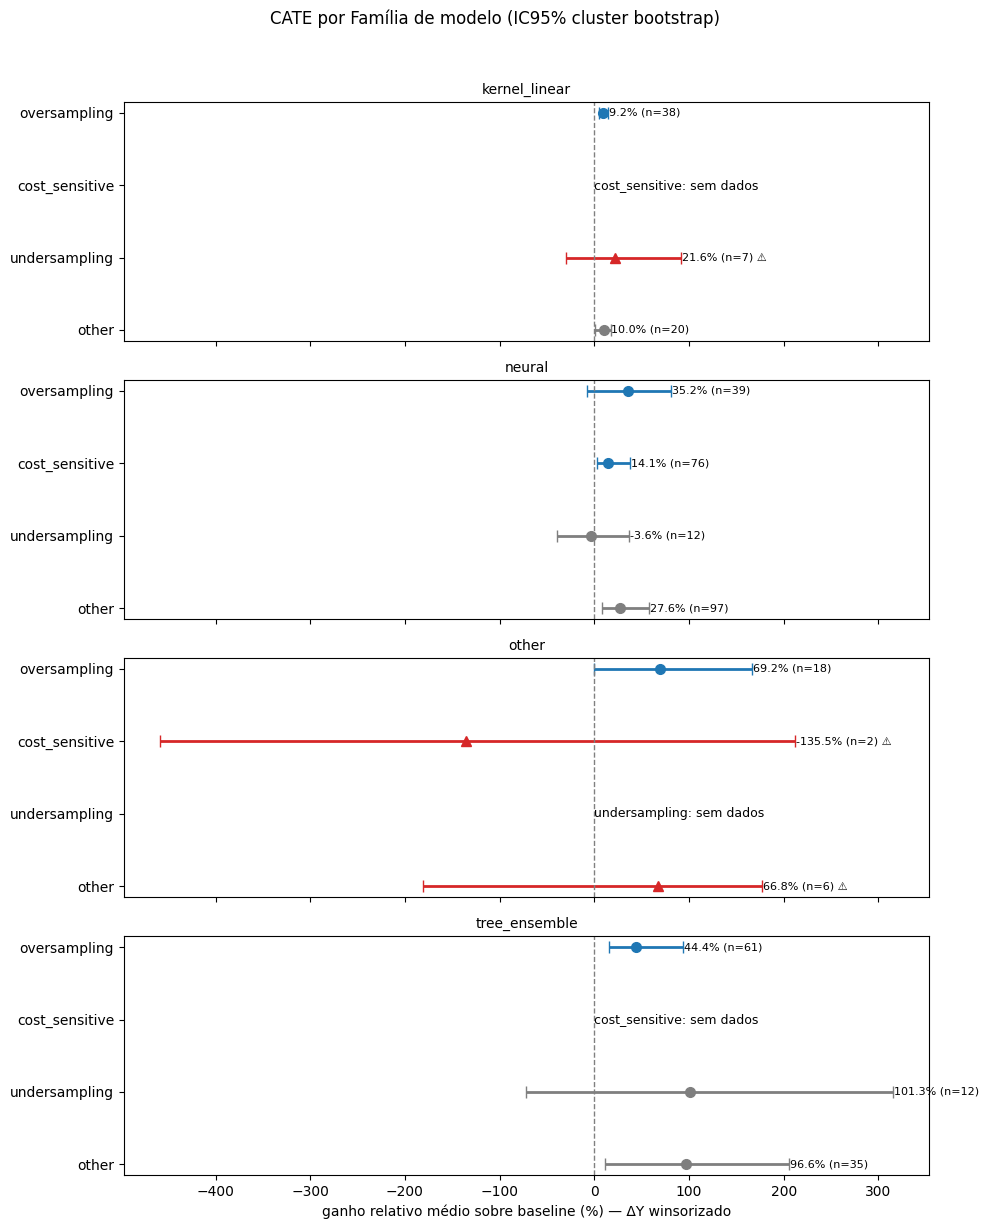

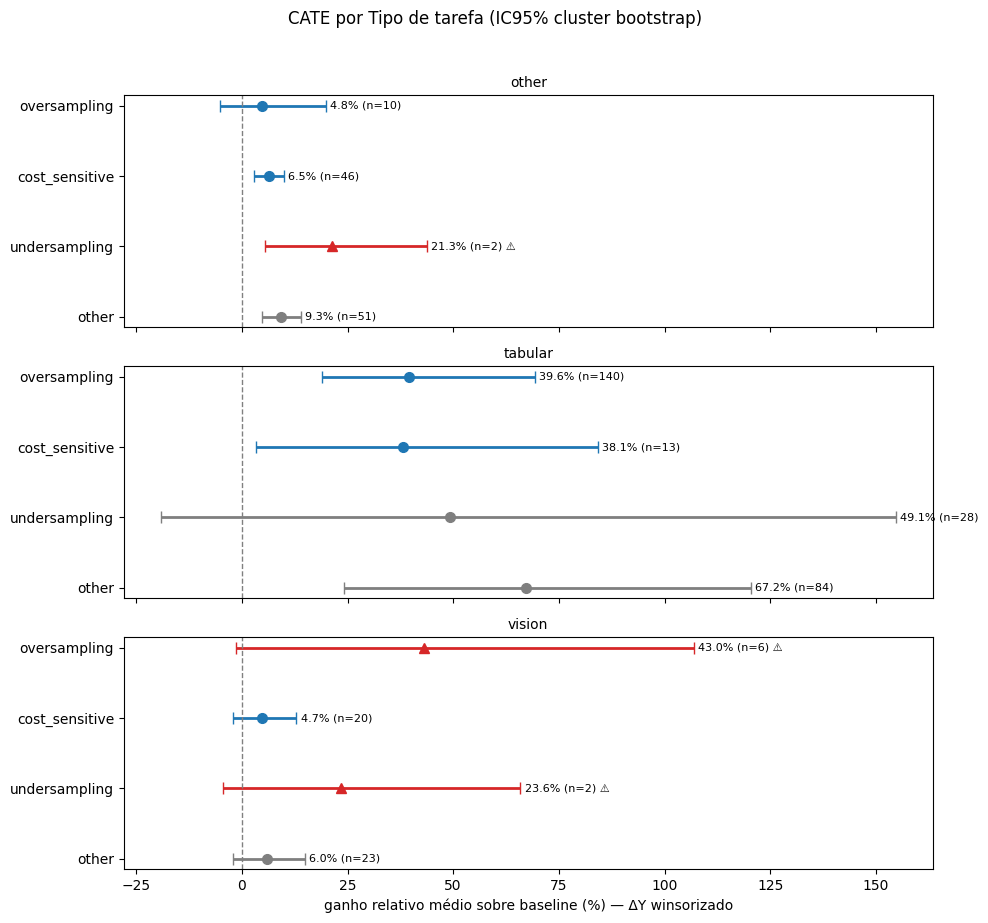

In [16]:
def plot_cate_forest(cate_df, dimension, dim_label):
    """Forest plot do CATE para uma dimensão de heterogeneidade."""
    subgroups = sorted(cate_df["subgrupo"].unique())
    n_sub = len(subgroups)
    
    fig, axes = plt.subplots(n_sub, 1, figsize=(10, 3 * n_sub),
                             sharex=True)
    if n_sub == 1:
        axes = [axes]
    
    for ax, sg in zip(axes, subgroups):
        sub = cate_df[cate_df["subgrupo"] == sg]
        ypos = np.arange(len(STRATS))[::-1]
        
        for y, s in zip(ypos, STRATS):
            row = sub[sub["estratégia"] == s]
            if row.empty or pd.isna(row["efeito % (wins.)"].values[0]):
                ax.text(0, y, f"{s}: sem dados", va="center", fontsize=9)
                continue
            eff = row["efeito % (wins.)"].values[0]
            lo_ = row["IC95% baixo"].values[0]
            hi_ = row["IC95% alto"].values[0]
            is_low_n = row["n_baixo"].values[0]
            n_val    = row["n"].values[0]
            
            color = "C3" if is_low_n else ("C0" if s in PRINCIPAIS else "C7")
            marker = "^" if is_low_n else "o"
            
            # Se lo_ ou hi_ for nan mas tivermos eff
            if pd.isna(lo_) or pd.isna(hi_):
                ax.plot(eff, y, marker=marker, color=color, markersize=7)
            else:
                ax.errorbar(eff, y, xerr=[[eff - lo_], [hi_ - eff]], fmt=marker,
                            color=color, capsize=4, lw=2, markersize=7)
                            
            label = f"{eff:.1f}% (n={n_val})"
            if is_low_n:
                label += " ⚠"
                
            x_pos = hi_ + 1 if not pd.isna(hi_) else eff + 1
            ax.text(x_pos, y, label, va="center", fontsize=8)
        
        ax.axvline(0, color="gray", ls="--", lw=1)
        ax.set_yticks(ypos)
        ax.set_yticklabels(STRATS)
        ax.set_title(f"{sg}", fontsize=10)
    
    axes[-1].set_xlabel("ganho relativo médio sobre baseline (%) — ΔY winsorizado")
    fig.suptitle(f"CATE por {dim_label} (IC95% cluster bootstrap)", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

for dim, label in HETEROG_DIMS.items():
    cate_dim = cate_all[cate_all["dimensão"] == dim]
    plot_cate_forest(cate_dim, dim, label)


## Visualização: Heatmap consolidado


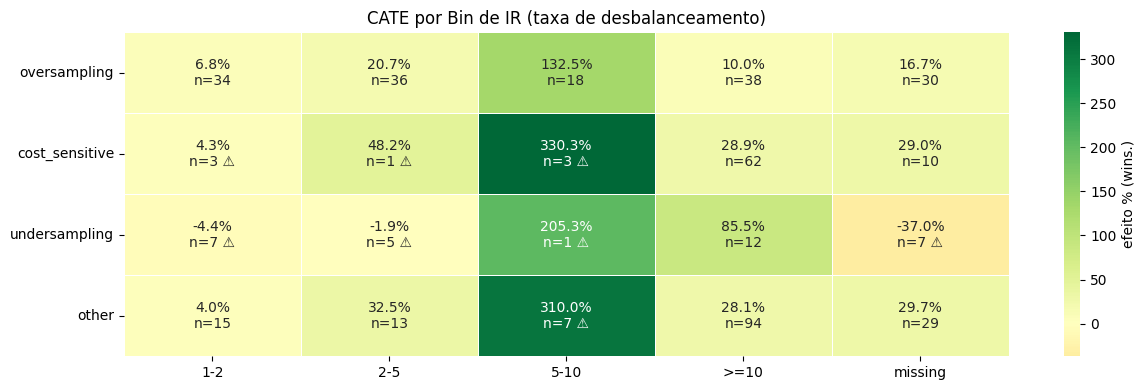

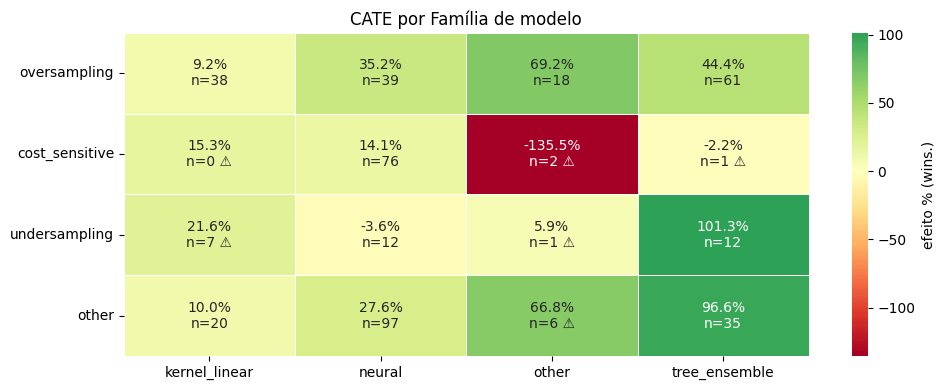

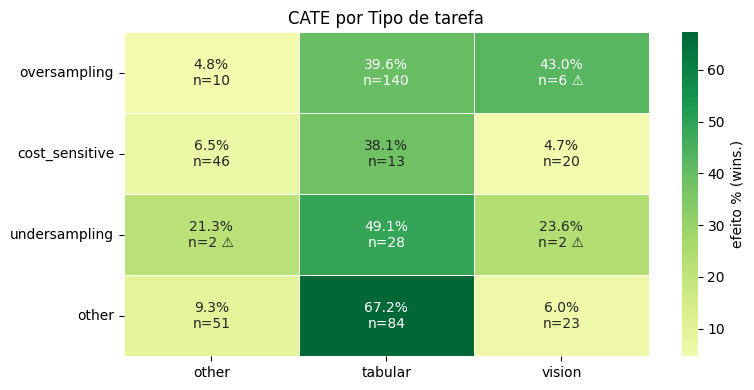

In [17]:
def plot_cate_heatmap(cate_df, dimension, dim_label):
    """Heatmap do CATE (efeito %) para uma dimensão."""
    pivot = cate_df.pivot_table(
        index="estratégia", columns="subgrupo",
        values="efeito % (wins.)", aggfunc="first"
    ).reindex(STRATS)
    
    pivot_n = cate_df.pivot_table(
        index="estratégia", columns="subgrupo",
        values="n", aggfunc="first"
    ).reindex(STRATS)
    
    # Anotações: efeito + n
    annot = pivot.copy().astype(str)
    for s in STRATS:
        for sg in pivot.columns:
            eff_val = pivot.loc[s, sg] if s in pivot.index else np.nan
            n_val   = pivot_n.loc[s, sg] if s in pivot_n.index else 0
            if pd.isna(eff_val):
                annot.loc[s, sg] = "—"
            else:
                marker = " ⚠" if n_val < N_MIN else ""
                annot.loc[s, sg] = f"{eff_val:.1f}%\nn={int(n_val)}{marker}"
    
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 2.5), 4))
    sns.heatmap(pivot, annot=annot, fmt="", cmap="RdYlGn", center=0,
                linewidths=0.5, ax=ax, cbar_kws={"label": "efeito % (wins.)"})
    ax.set_title(f"CATE por {dim_label}")
    ax.set_ylabel(""); ax.set_xlabel("")
    plt.tight_layout()
    plt.show()

for dim, label in HETEROG_DIMS.items():
    cate_dim = cate_all[cate_all["dimensão"] == dim]
    plot_cate_heatmap(cate_dim, dim, label)
